In [1]:
import numpy as np
from heapy.util.coord import *
from heapy.geos.geometry import gbmGeometry
from heapy.geos.localization import gbmHealPix

In [2]:
geom = gbmGeometry('./glg_poshist_all_170101_v00.fit')

In [3]:
geom.gti

[(504921540.740104, 504924818.340072),
 (504925227.340079, 504962247.340076),
 (504963081.340078, 504967992.340078),
 (504969383.340077, 504973833.340077),
 (504975419.340078, 504979728.340076),
 (504981395.340078, 504985767.340077),
 (504987345.340078, 504991938.340124),
 (504993281.340069, 504998034.340079),
 (504999211.340076, 505004088.340077),
 (505005126.34007, 505008061.340078)]

In [4]:
t0 = 504975500.0

lat, lon, alt = geom.get_coords_itrs(t0)
print('Latitude: {:.2f}'.format(lat))
print('Longitude: {:.2f}'.format(lon))
print('Altitude: {:.2f} km'.format(alt))

Latitude: -23.47
Longitude: 26.74
Altitude: 544.54 km


In [5]:
geom.get_saa_passage(t0)

False

In [6]:
geocenter = geom.get_geocenter_radec(t0)
georadius = geom.get_earth_angular_radius(t0)
print("Geocenter RA, Dec = {0:.2f}, {1:.2f}".format(*geocenter))
print('Earth radius: {:.2f} deg'.format(georadius))

Geocenter RA, Dec = 172.53, 23.43
Earth radius: 67.12 deg


In [7]:
geom.get_sun_visible(t0)

True

In [8]:
ra = 324.3
dec = -20.8
geom.get_location_visible(ra, dec, t0)

True

In [9]:
geom.get_detector_pointing('n0', t0)

(327.8802325489804, -18.180145455092887)

In [10]:
geom.get_detector_angle(ra, dec, 'n0', t0)

4.272198241248021

In [11]:
geom.to_fermi_frame(ra, dec, t0)

(39.67934935255249, 24.144642909720986)

In [12]:
geom.to_sky_frame(0.0, 0.0, t0)

(333.15398865700126, 1.734307849725122)

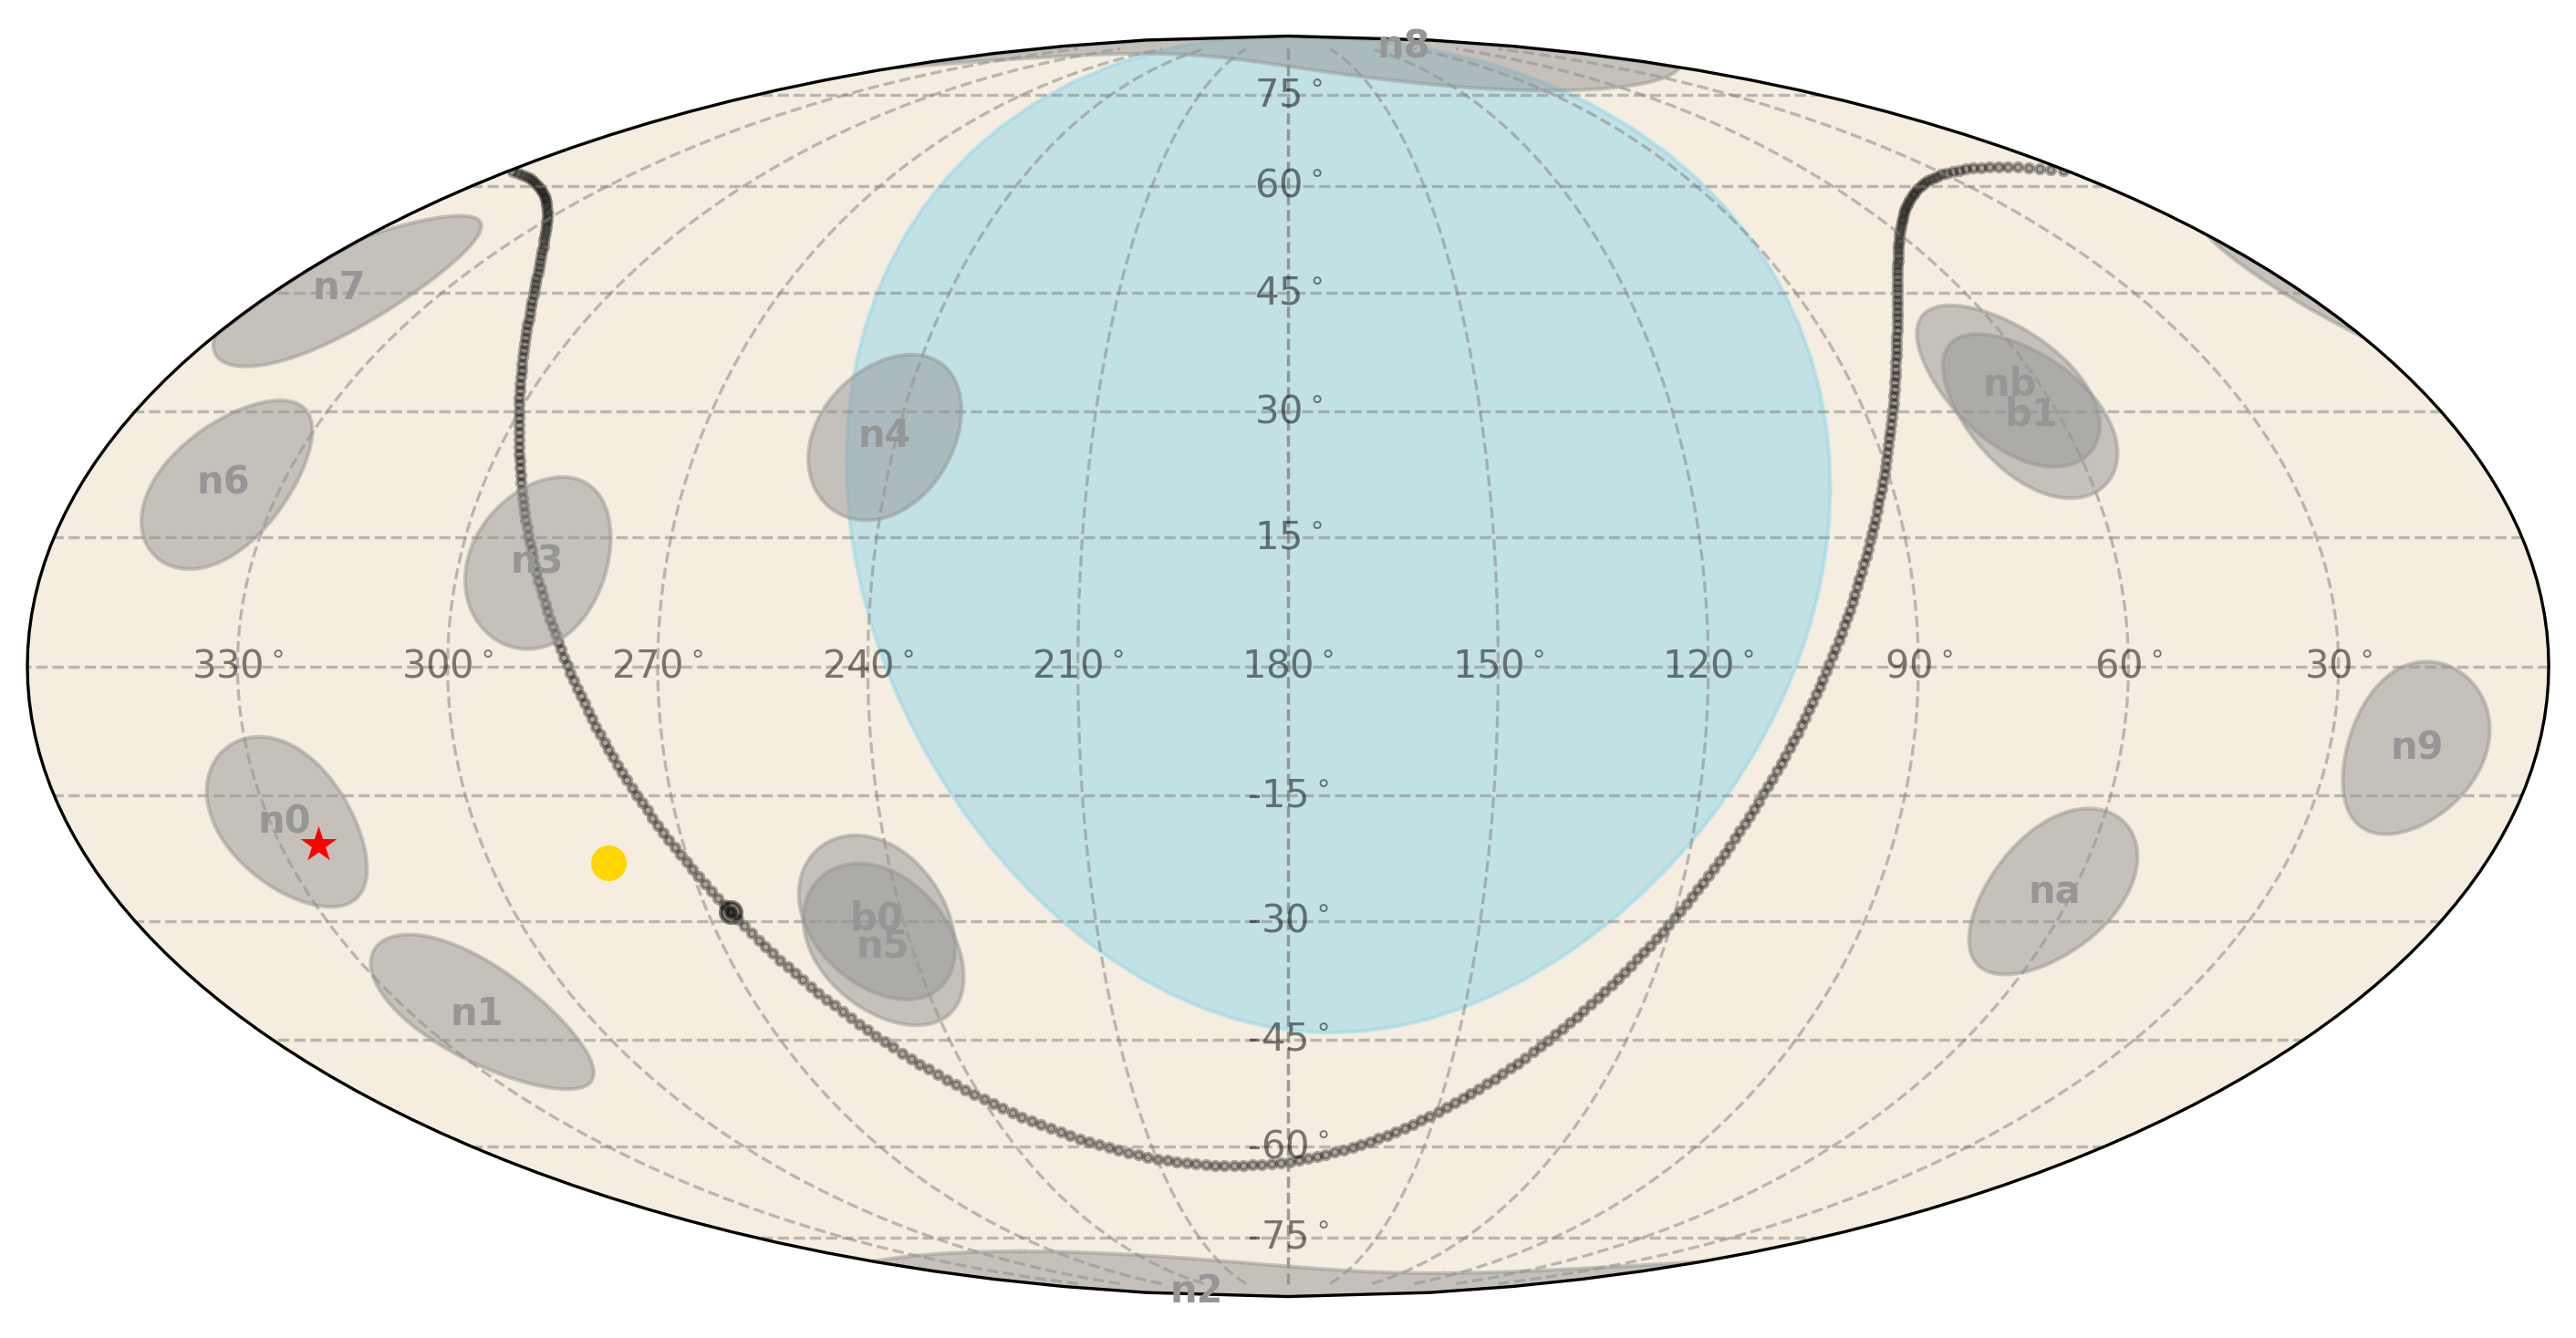

In [13]:
geom.extract_skymap(t0, ra, dec)

In [14]:
heal = gbmHealPix('./glg_healpix_all_bn190915240_v00.fit')

In [15]:
print('Healpix nside: {}'.format(heal.nside))
print('Healpix npix: {}'.format(heal.npix))
print('Pixel area (sq. deg.): {}'.format(heal.pixel_area))

Healpix nside: 128
Healpix npix: 196608
Pixel area (sq. deg.): 0.20982341130279172


In [16]:
heal.centroid

(48.8671875, 4.181528273111476)

In [17]:
heal.get_probability(49.0, 4.0)

0.009200396515918592

In [18]:
heal.get_confidence(40.0, 4.0)

0.865783539232832

In [19]:
heal.get_confidence_area(0.9)

281.1633711457409

In [20]:
heal.get_confidence_contours(0.5)

[array([[ 4.61281337e+01,  2.59721684e-01],
        [ 4.53138456e+01,  5.02793296e-01],
        [ 4.51253482e+01,  6.21222158e-01],
        [ 4.43160678e+01,  1.50837989e+00],
        [ 4.41225627e+01,  2.36616334e+00],
        [ 4.40920226e+01,  2.51396648e+00],
        [ 4.38604591e+01,  3.51955307e+00],
        [ 4.38130019e+01,  4.52513966e+00],
        [ 4.41225627e+01,  5.23313031e+00],
        [ 4.43770701e+01,  5.53072626e+00],
        [ 4.50410902e+01,  6.53631285e+00],
        [ 4.51253482e+01,  6.62602574e+00],
        [ 4.61281337e+01,  7.28272773e+00],
        [ 4.66920493e+01,  7.54189944e+00],
        [ 4.71309192e+01,  7.65985809e+00],
        [ 4.81337047e+01,  7.71980664e+00],
        [ 4.91364903e+01,  8.00964739e+00],
        [ 5.01392758e+01,  8.17249974e+00],
        [ 5.11420613e+01,  7.90708921e+00],
        [ 5.21448468e+01,  7.74393795e+00],
        [ 5.25325054e+01,  7.54189944e+00],
        [ 5.31476323e+01,  7.20106255e+00],
        [ 5.41504178e+01,  6.998

In [21]:
print(heal.get_association_probability(50.0, 10.0))
print(heal.get_association_probability(150.0, 10.0))

0.9873891231756146
4.4060124762002806e-15


In [22]:
print('Sun location: {}'.format(heal.sun_location))
print('Geocenter location: {}'.format(heal.geo_location))
print('Geocenter radius: {} deg'.format(heal.geo_radius))
print('Detector n0 pointing: {}'.format(heal.n0_pointing))
print('Fraction of localization on Earth {}'.format(heal.earth_occulted_probability))

Sun location: (172.5011935415178, 3.23797213866954)
Geocenter location: (319.8312390218318, 17.40612934717674)
Geocenter radius: 67.2950460311874 deg
Detector n0 pointing: (146.5959532829778, 36.96759511828569)
Fraction of localization on Earth 8.442886610282585e-06


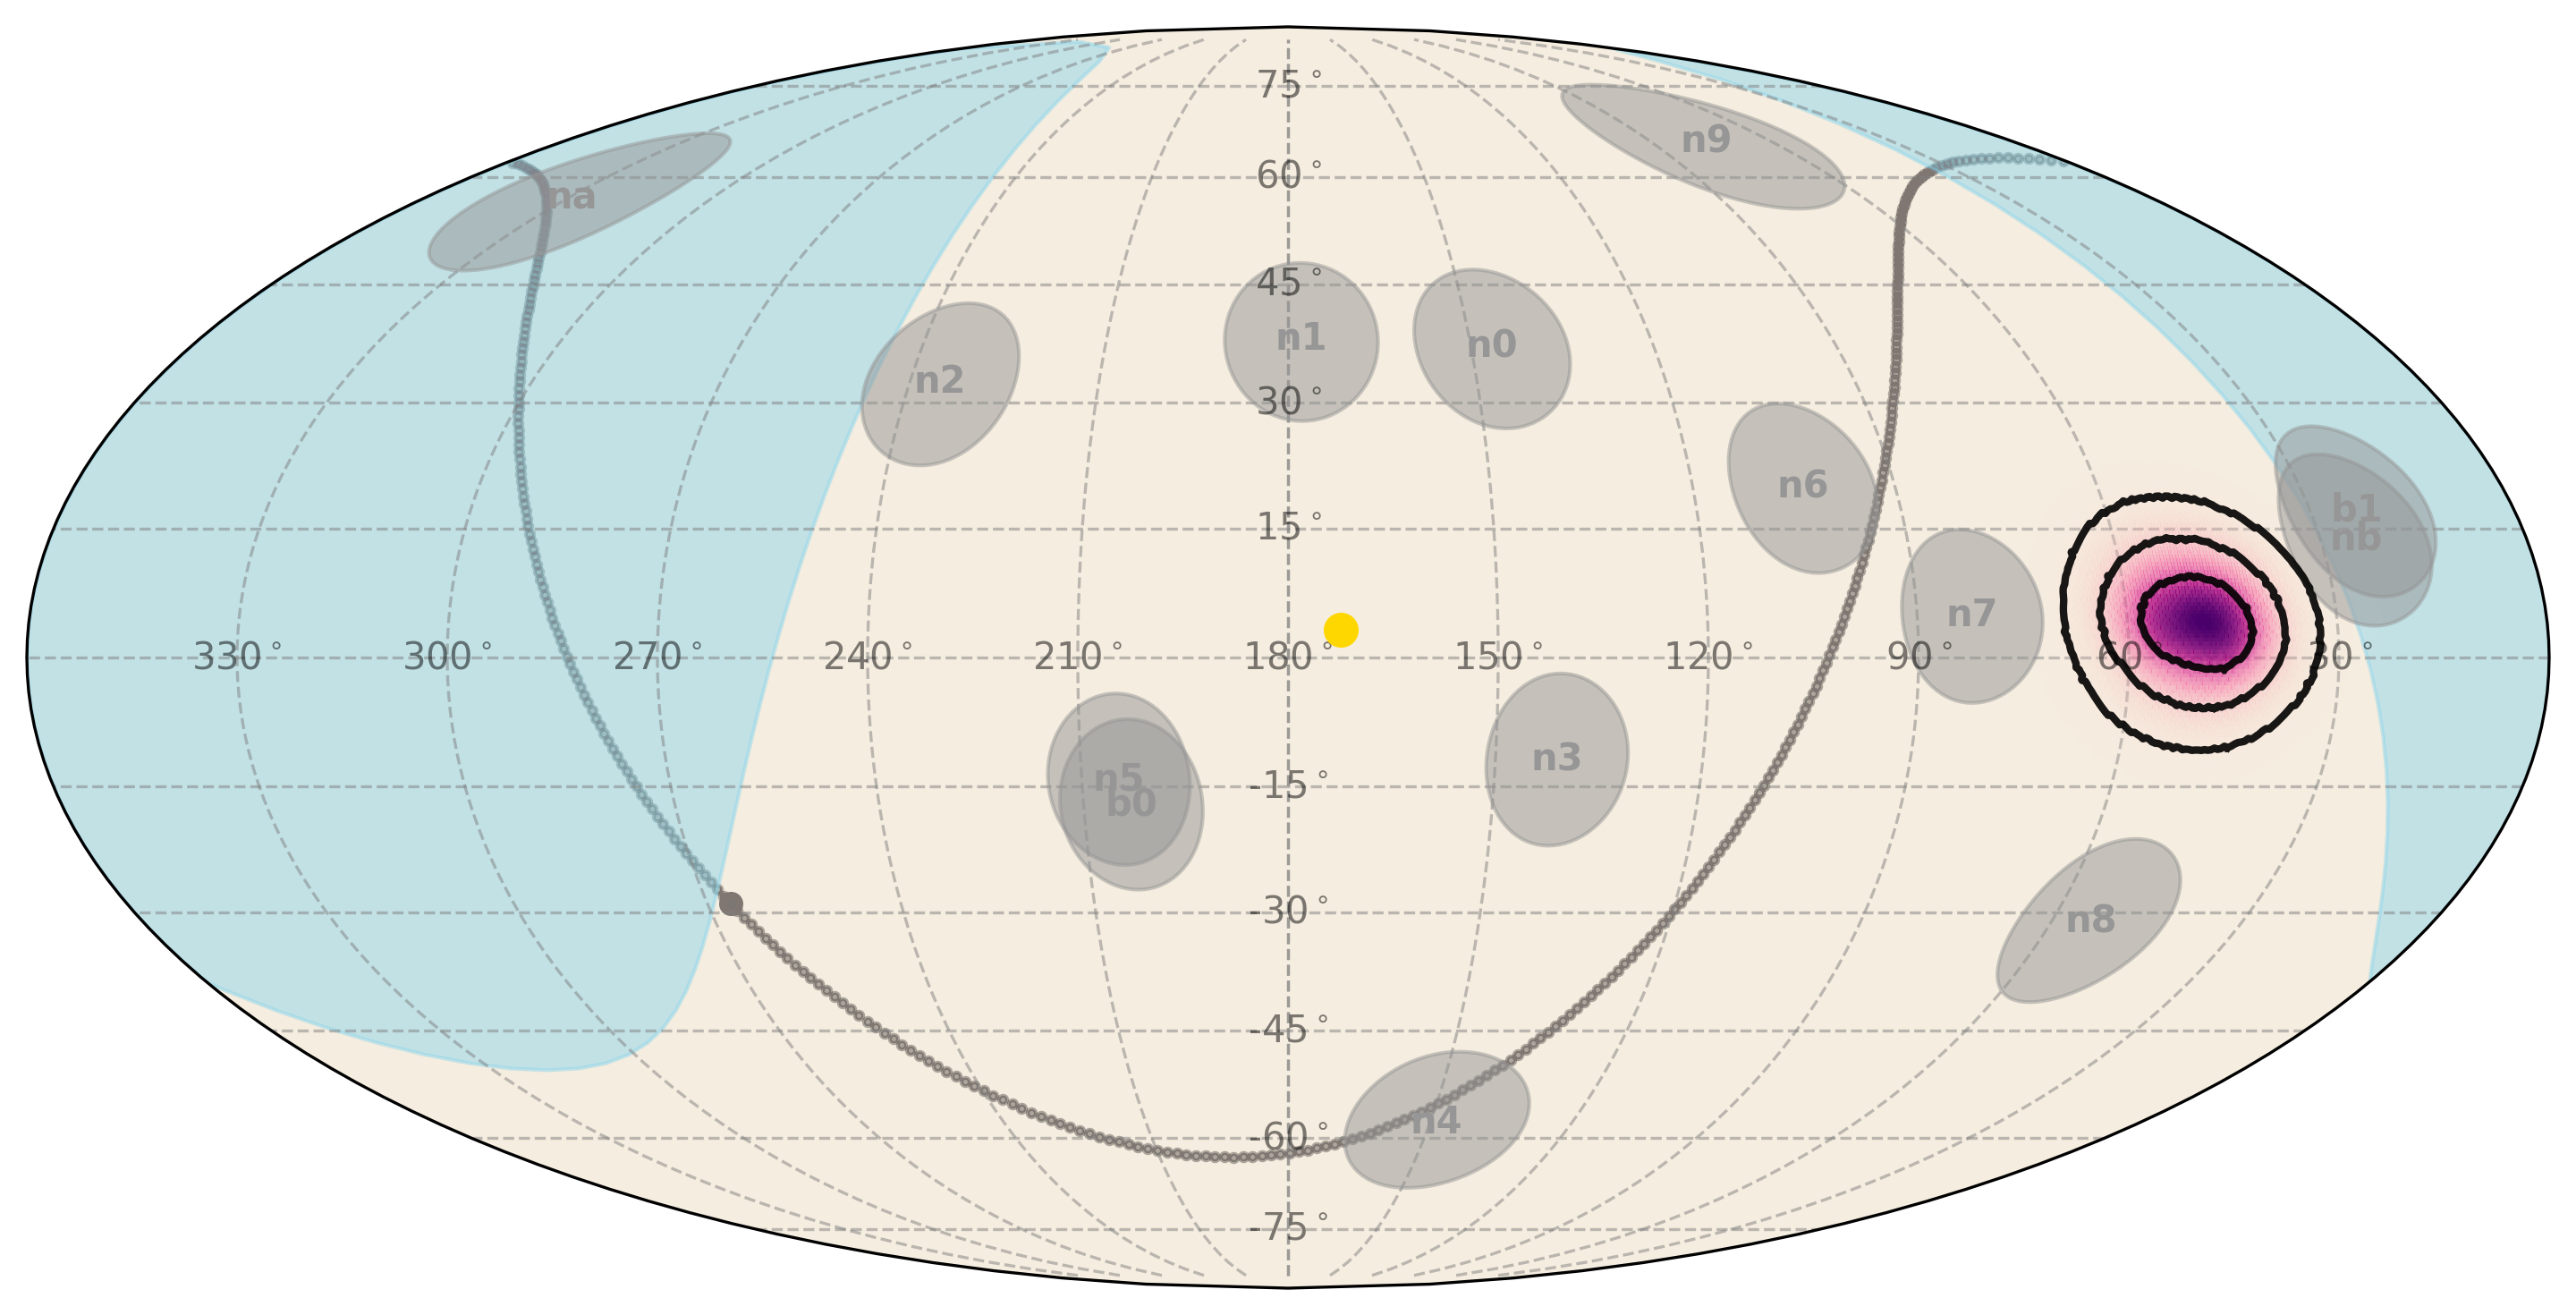

In [23]:
heal.extract_skymap()